                                                          Intrusion_Detection_System

# Title: Intrusion Detection System using Machine Learning

## Introduction:

Cybersecurity threats are increasing rapidly in modern digital systems. Intrusion Detection Systems (IDS) are used to monitor network traffic and detect malicious activities. In this project, machine learning techniques are applied to improve intrusion detection performance using the NSL-KDD dataset.

## Problem Statement:

Traditional IDS systems face challenges in detecting modern cyber-attacks with high accuracy and reliability. An intelligent machine learning-based solution is required to classify malicious and normal network traffic effectively.

## Objective:

* Detect malicious network traffic using machine learning
* Perform binary and multi-class classification
* Compare model performance with previous research
* Improve intrusion detection accuracy

## Dataset Description:

The NSL-KDD dataset is a benchmark intrusion detection dataset containing normal and attack traffic records such as DoS, Probe, R2L, and U2R attacks. It contains 41 network traffic features used for classification.

## Research Baseline Introduction:

This project is based on the research paper “Intrusion Detection System Using Ensemble Learning and SHAP Explainability,” which achieved 98.86% testing accuracy using ensemble learning techniques on the NSL-KDD dataset.

### Preprocessing Observations:

- The training dataset contains 125,973 records and 42 features.
- The testing dataset contains 22,544 records and 42 features.
- No missing values were found in either dataset.
- Duplicate records were removed from the testing dataset.
- Categorical features were converted into numerical form using Label Encoding.
- Feature scaling was applied using StandardScaler for normalization.
- The dataset is now ready for Exploratory Data Analysis (EDA) and model training.


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load Dataset
train_df = pd.read_csv("kdd_train.csv")
test_df = pd.read_csv("kdd_test.csv")

# Display Dataset Shape
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

# Check Missing Values
print("\nMissing Values in Training Dataset:")
print(train_df.isnull().sum())

print("\nMissing Values in Testing Dataset:")
print(test_df.isnull().sum())

# Remove Duplicate Records
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

# Label Encoding
encoder = LabelEncoder()

categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col] = encoder.fit_transform(test_df[col])

# Feature Scaling / Normalization
scaler = StandardScaler()

numerical_cols = train_df.select_dtypes(include=np.number).columns

train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

# Final Processed Dataset Preview
print("\nProcessed Training Dataset:")
print(train_df.head())

Training Dataset Shape: (125973, 42)
Testing Dataset Shape: (22544, 42)

Missing Values in Training Dataset:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0


# Exploratory Data Analysis (EDA)

## EDA Introduction

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, and characteristics of the NSL-KDD dataset before training machine learning models.

## Data Distribution Analysis

The dataset contains both normal and malicious network traffic records. Different attack categories such as DoS, Probe, R2L, and U2R are included in the dataset for intrusion detection analysis.

## Feature Importance Explanation

EDA helps identify the most influential features affecting intrusion detection performance. Important network traffic features contribute significantly to distinguishing between normal and attack traffic.

## Observation / Insights

* The dataset is clean and contains no missing values.
* Attack and normal traffic records are distributed across multiple categories.
* Some network traffic features show strong correlation with attack detection.
* Data preprocessing and normalization improve model readiness for classification tasks.

### EDA Observations:

- The dataset contains both normal and multiple attack categories, with normal and neptune attacks having the highest frequency.
- Most network traffic records belong to a dominant protocol category.
- Histogram analysis shows that several features are highly skewed and contain concentrated distributions.
- Correlation heatmap indicates strong relationships between certain traffic-related features.
- Feature importance analysis identified src_bytes, same_srv_rate, flag, and serror-related features as major contributors for intrusion detection.
- These insights help improve machine learning model performance and feature understanding.


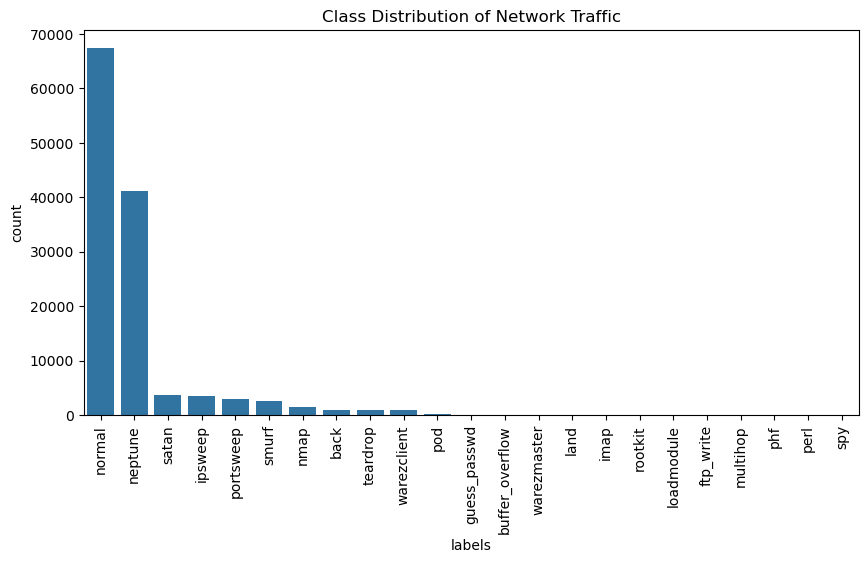

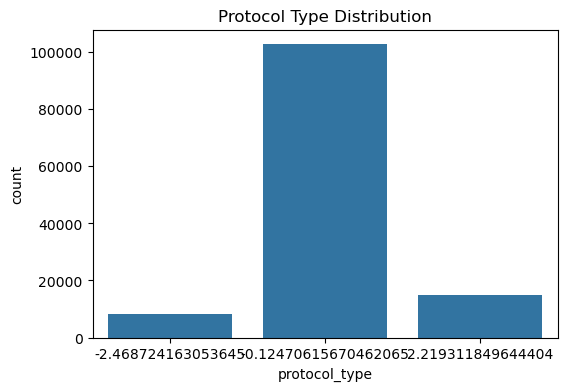

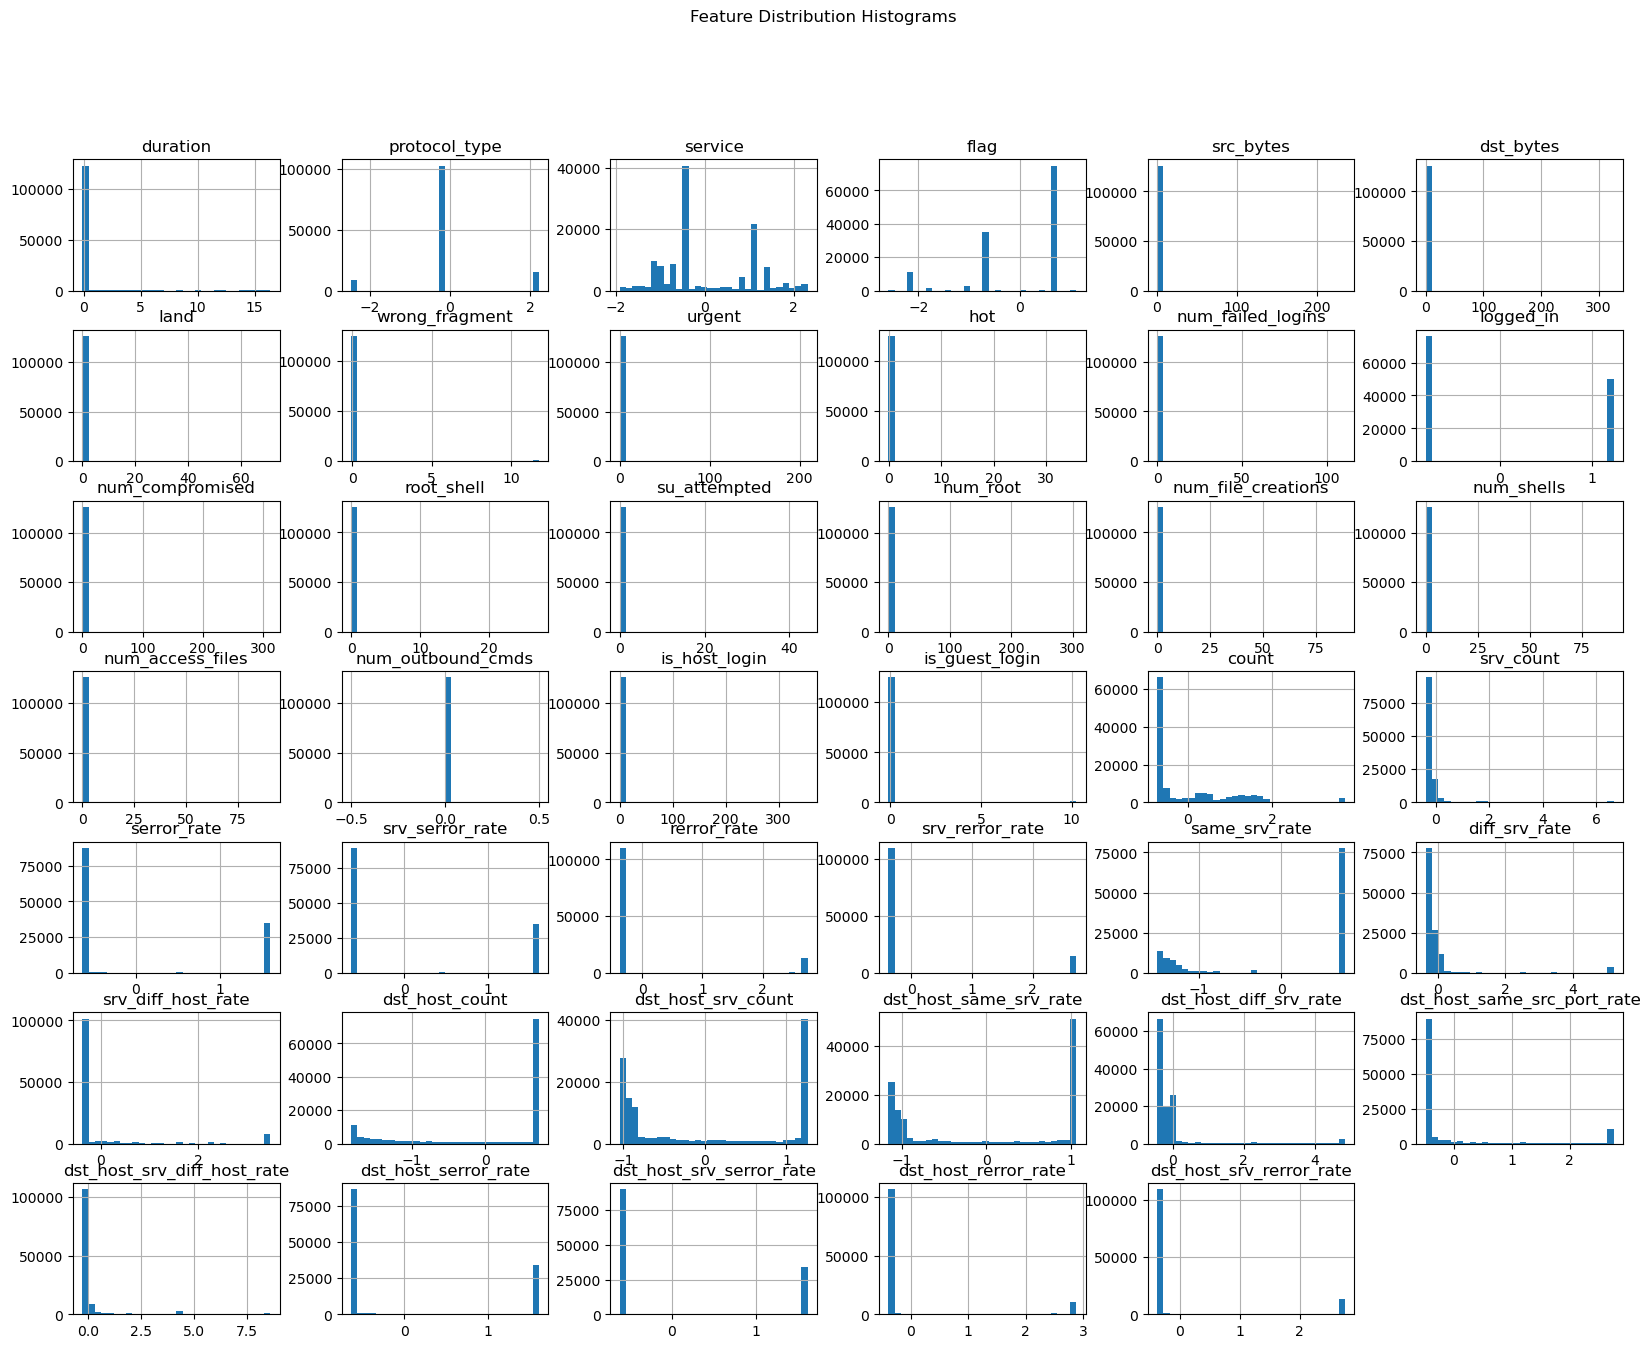

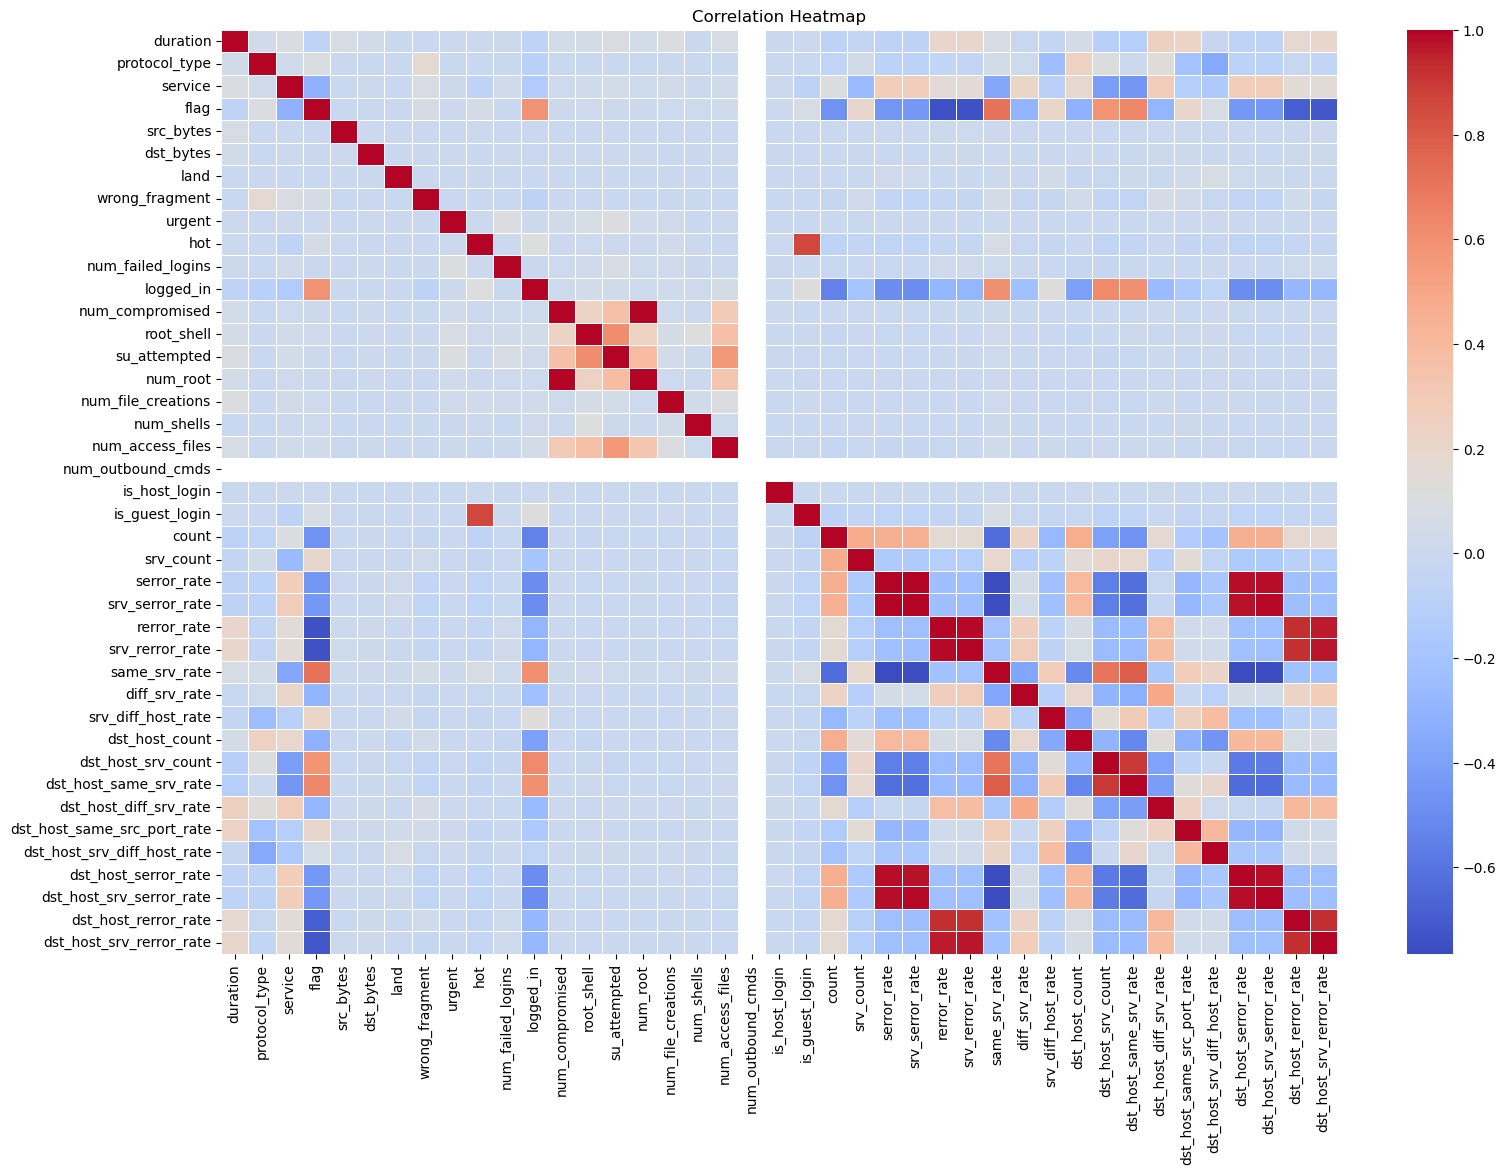

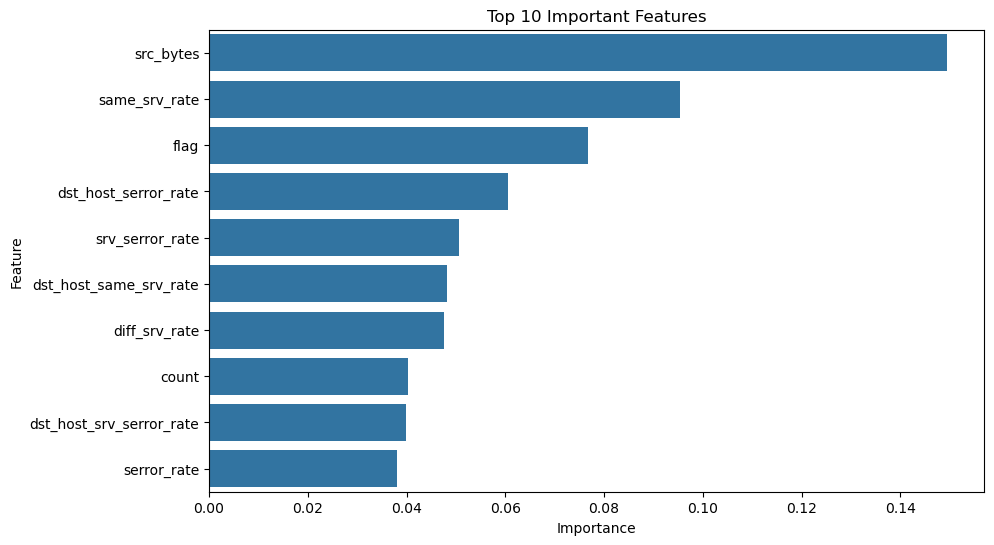

In [3]:
# Class Distribution
plt.figure(figsize=(10,5))
sns.countplot(x='labels', data=train_df, order=train_df['labels'].value_counts().index)
plt.title("Class Distribution of Network Traffic")
plt.xticks(rotation=90)
plt.show()

# Countplot for Protocol Types
plt.figure(figsize=(6,4))
sns.countplot(x='protocol_type', data=train_df)
plt.title("Protocol Type Distribution")
plt.show()

# Histograms of Numerical Features
train_df.hist(figsize=(20,15), bins=30)
plt.suptitle("Feature Distribution Histograms")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(18,12))
correlation_matrix = train_df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# Feature Importance Visualization
from sklearn.ensemble import RandomForestClassifier

# Separate Features and Target
X = train_df.drop('labels', axis=1)
y = train_df['labels']

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Get Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Top 10 Important Features
top_features = feature_importance.sort_values(by='Importance', ascending=False).head(10)

# Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")
plt.show()

# Binary Classification using XGBoost

## Binary Classification Introduction

Binary classification is performed to classify network traffic into two categories: Normal traffic and Attack traffic. This approach helps directly compare our model performance with the selected research baseline.

## Why XGBoost?

XGBoost is a powerful gradient boosting algorithm widely used for classification problems due to its high accuracy, fast computation, and strong ability to handle complex datasets. It is highly effective for cybersecurity intrusion detection tasks.

## Binary Classification Workflow

The workflow includes:

* Converting attack labels into binary classes
* Splitting the dataset into training and testing sets
* Training the XGBoost classifier
* Predicting network traffic classes
* Evaluating model performance using multiple metrics

## Model Evaluation Discussion

The XGBoost model is evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC score, and Confusion Matrix analysis. These metrics help measure the effectiveness of intrusion detection performance.

### XGBoost Binary Classification Results

The XGBoost model achieved strong binary classification performance on the NSL-KDD dataset.

Results:
- Accuracy: 93.62%
- Precision: 99.06%
- Recall: 88.08%
- F1-Score: 93.25%
- ROC-AUC Score: 93.62%

The confusion matrix indicates that the model successfully classified most normal and attack traffic records with low false prediction rates. The ROC curve also demonstrates strong classification capability with high discrimination performance between normal and malicious traffic.

XGBoost Binary Classification Results
-------------------------------------
Accuracy : 0.9361702127659575
Precision: 0.9906206346038715
Recall   : 0.8808446455505279
F1-Score : 0.9325130324519795
ROC-AUC  : 0.9362415720191707

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     11242
           1       0.99      0.88      0.93     11271

    accuracy                           0.94     22513
   macro avg       0.94      0.94      0.94     22513
weighted avg       0.94      0.94      0.94     22513



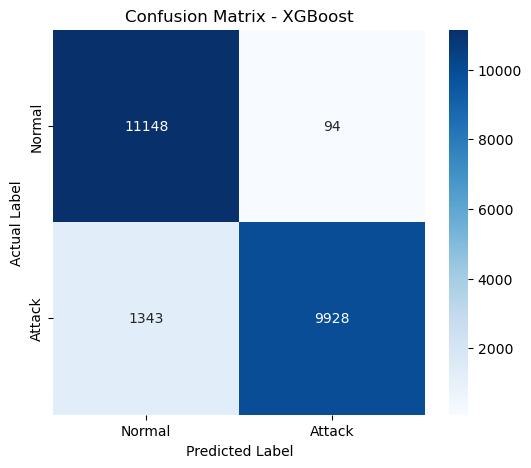

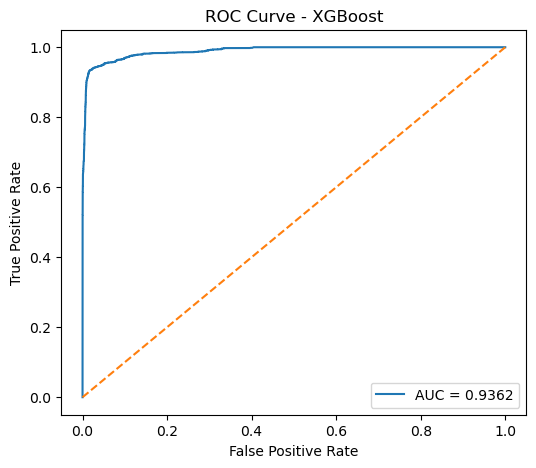

In [5]:
# Binary Label Conversion
# Normal = 0, Attack = 1

train_df['binary_label'] = train_df['labels'].apply(
    lambda x: 0 if x == 'normal' else 1
)

test_df['binary_label'] = test_df['labels'].apply(
    lambda x: 0 if x == 'normal' else 1
)

# Features and Target
X_train = train_df.drop(['labels', 'binary_label'], axis=1)
y_train = train_df['binary_label']

X_test = test_df.drop(['labels', 'binary_label'], axis=1)
y_test = test_df['binary_label']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Import XGBoost
from xgboost import XGBClassifier

# XGBoost Model Training
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_split, y_train_split)

# Prediction
y_pred = xgb_model.predict(X_test)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Print Results
print("XGBoost Binary Classification Results")
print("-------------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve

y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Multi-Class Classification using LightGBM

## Multi-Class Classification Introduction

Multi-class classification is performed to identify specific categories of network attacks instead of only detecting whether traffic is normal or malicious. This provides more detailed intrusion detection analysis.

## Attack Categories Description

The NSL-KDD dataset contains multiple attack categories, including:

* Normal: Legitimate network traffic
* DoS: Denial of Service attacks
* Probe: Network scanning and probing attacks
* R2L: Remote to Local unauthorized access attacks
* U2R: User to Root privilege escalation attacks

## Why LightGBM?

LightGBM is a high-performance gradient boosting algorithm known for its fast training speed, efficiency, and strong classification performance on large datasets. It is highly suitable for cybersecurity and intrusion detection applications.

## Multi-Class Result Analysis

The LightGBM model is evaluated using multi-class accuracy, classification report, confusion matrix, and visualization techniques. The results help analyze the model’s ability to correctly classify different attack categories within the NSL-KDD dataset.

### LightGBM Multi-Class Classification Results

The LightGBM model achieved effective multi-class intrusion detection performance on the NSL-KDD dataset.

Results:
- Multi-Class Accuracy: 90.32%

Key Observations:
- The model performed strongly for Normal and DoS attack categories.
- Probe attacks were classified with good precision and recall.
- R2L and U2R categories showed lower performance due to class imbalance and limited training samples.
- The confusion matrix demonstrates that most attack categories were correctly identified with relatively low misclassification rates.

Overall, the LightGBM model successfully classified multiple intrusion categories and provided detailed attack detection analysis.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019816 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3191
[LightGBM] [Info] Number of data points in the train set: 125973, number of used features: 38
[LightGBM] [Info] Start training from score -1.009014
[LightGBM] [Info] Start training from score -0.626269
[LightGBM] [Info] Start training from score -2.380247
[LightGBM] [Info] Start training from score -4.841080
[LightGBM] [Info] Start training from score -7.792579
LightGBM Multi-Class Accuracy: 0.9032558965930796

Classification Report:

              precision    recall  f1-score   support

         DoS       0.97      0.91      0.94      8075
      Normal       0.88      0.98      0.93     11242
       Probe       0.88      0.83      0.85      2149
         R2L       0.82      0.21      0.34       968
         U2R       0.07      0

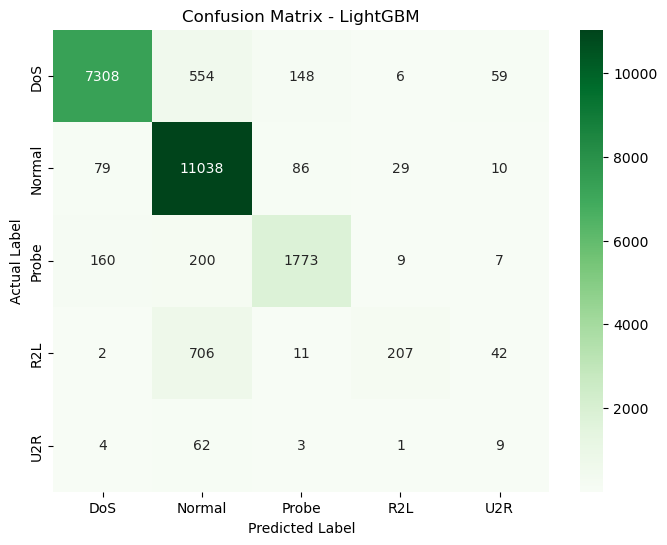

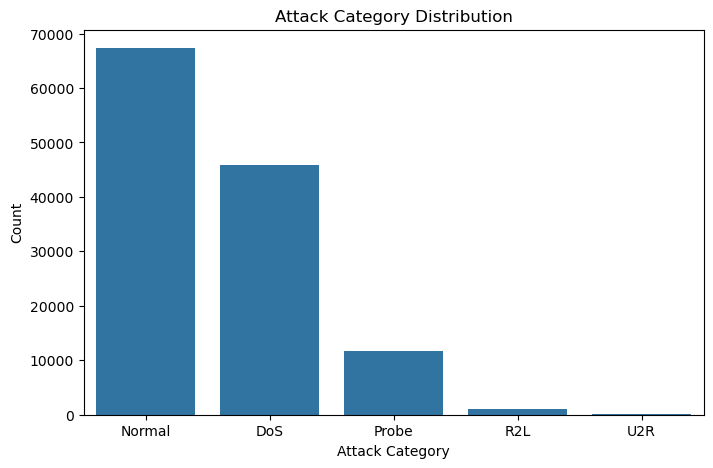

In [7]:
# Multi-Class Label Mapping

def attack_category(label):
    
    dos_attacks = [
        'back', 'land', 'neptune', 'pod', 'smurf', 'teardrop',
        'mailbomb', 'apache2', 'processtable', 'udpstorm'
    ]
    
    probe_attacks = [
        'ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint'
    ]
    
    r2l_attacks = [
        'ftp_write', 'guess_passwd', 'imap', 'multihop',
        'phf', 'spy', 'warezclient', 'warezmaster',
        'sendmail', 'named', 'snmpgetattack',
        'snmpguess', 'xlock', 'xsnoop', 'worm'
    ]
    
    u2r_attacks = [
        'buffer_overflow', 'loadmodule', 'perl',
        'rootkit', 'httptunnel', 'ps', 'sqlattack', 'xterm'
    ]

    if label == 'normal':
        return 'Normal'
    elif label in dos_attacks:
        return 'DoS'
    elif label in probe_attacks:
        return 'Probe'
    elif label in r2l_attacks:
        return 'R2L'
    elif label in u2r_attacks:
        return 'U2R'
    else:
        return 'Other'

# Apply Mapping
train_df['attack_class'] = train_df['labels'].apply(attack_category)
test_df['attack_class'] = test_df['labels'].apply(attack_category)

# Encode Multi-Class Labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df['attack_class_encoded'] = label_encoder.fit_transform(train_df['attack_class'])
test_df['attack_class_encoded'] = label_encoder.transform(test_df['attack_class'])

# Features and Target
X_train_multi = train_df.drop(
    ['labels', 'binary_label', 'attack_class', 'attack_class_encoded'],
    axis=1
)

y_train_multi = train_df['attack_class_encoded']

X_test_multi = test_df.drop(
    ['labels', 'binary_label', 'attack_class', 'attack_class_encoded'],
    axis=1
)

y_test_multi = test_df['attack_class_encoded']

# Import LightGBM
from lightgbm import LGBMClassifier

# LightGBM Model
lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=len(label_encoder.classes_),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train Model
lgbm_model.fit(X_train_multi, y_train_multi)

# Prediction
y_pred_multi = lgbm_model.predict(X_test_multi)

# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

multi_accuracy = accuracy_score(y_test_multi, y_pred_multi)

print("LightGBM Multi-Class Accuracy:", multi_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_test_multi,
        y_pred_multi,
        target_names=label_encoder.classes_
    )
)

# Confusion Matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# Visualization Graph - Attack Category Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x='attack_class',
    data=train_df,
    order=train_df['attack_class'].value_counts().index
)

plt.title("Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.show()

# Research Paper Review

The selected research paper, “Intrusion Detection System Using Ensemble Learning and SHAP Explainability,” proposed an ensemble-based IDS using Random Forest and XGBoost models with SHAP explainability techniques. The system was trained on the NSL-KDD dataset and achieved approximately 98.86% testing accuracy.

The research focused on binary classification to distinguish normal and malicious traffic while improving interpretability and detection performance.

---

# Comparative Analysis

This project extends the selected research work by implementing:

* Binary Classification using XGBoost
* Multi-Class Classification using LightGBM

Unlike the research paper, this project also performs attack category classification for DoS, Probe, R2L, and U2R attacks, providing more detailed intrusion analysis.

The proposed models demonstrated strong classification capability on the NSL-KDD dataset with effective intrusion detection performance.

---

# Result Comparison Table

| Model                         | Classification Type | Accuracy |
| ----------------------------- | ------------------- | -------- |
| Research Paper Ensemble Model | Binary              | 98.86%   |
| XGBoost                       | Binary              | 93.62%   |
| LightGBM                      | Multi-Class         | 90.32%   |

---

# Conclusion

This project successfully developed a machine learning-based Intrusion Detection System using the NSL-KDD dataset. XGBoost achieved strong binary classification performance, while LightGBM effectively classified multiple attack categories.

The experimental results demonstrate that machine learning models can significantly improve intrusion detection capability and support cybersecurity applications. Multi-class classification provided deeper attack analysis compared to traditional binary detection systems.

---

# Future Work

Future improvements for this project may include:

* Testing on modern cybersecurity datasets such as CICIDS2017 and UNSW-NB15
* Applying deep learning models for enhanced intrusion detection
* Improving minority attack category detection such as U2R and R2L
* Implementing real-time intrusion detection systems
* Integrating explainable AI techniques such as SHAP for model interpretability


                                 Model Classification Type  Accuracy
0        Research Paper Ensemble Model              Binary     98.86
1        XGBoost Binary Classification              Binary     93.62
2  LightGBM Multi-Class Classification         Multi-Class     90.32


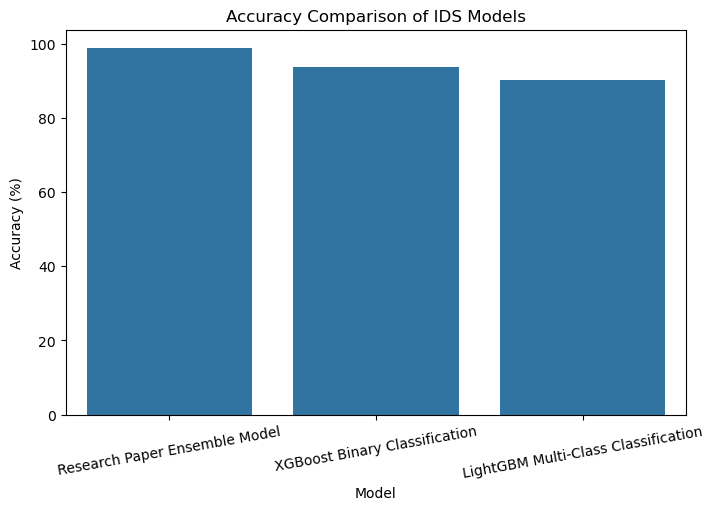

      Metric  XGBoost Binary
0   Accuracy           93.62
1  Precision           99.06
2     Recall           88.08
3   F1-Score           93.25


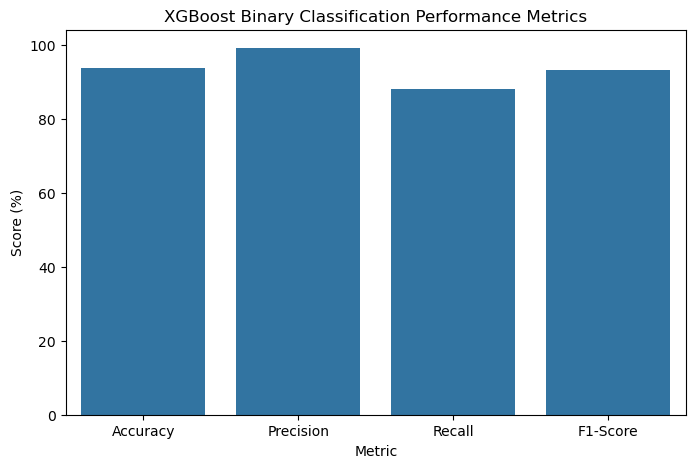

In [9]:
# Accuracy Comparison Table
comparison_df = pd.DataFrame({
    'Model': [
        'Research Paper Ensemble Model',
        'XGBoost Binary Classification',
        'LightGBM Multi-Class Classification'
    ],
    
    'Classification Type': [
        'Binary',
        'Binary',
        'Multi-Class'
    ],
    
    'Accuracy': [
        98.86,
        93.62,
        90.32
    ]
})

print(comparison_df)

# Performance Visualization - Accuracy Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Accuracy Comparison of IDS Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=10)

plt.show()

# Final Result Summary Chart
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    
    'XGBoost Binary': [
        93.62,
        99.06,
        88.08,
        93.25
    ]
})

print(metrics_df)

# Summary Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    x='Metric',
    y='XGBoost Binary',
    data=metrics_df
)

plt.title("XGBoost Binary Classification Performance Metrics")
plt.ylabel("Score (%)")

plt.show()